# Unique Baseline-Anchored Hybrid Training Pipeline

Bu notebook, baseline CNN+ViT modelini referans alarak **guvenli (non-inferiority constrained)** anchored modeller egitir.

Temel hedefler:
- Baglanti kopsa bile checkpoint ile egitime devam
- Tum metrikleri hesaplama (accuracy, precision/recall/f1 macro-weighted, specificity, roc_auc, qwk)
- En iyi modeli kaydetme
- Loss, accuracy ve confusion matrix gorselleri
- Nihai degerlendirme test seti uzerinde

Veri bolunmesi: 80-10-10 (APTOS2019 orijinal veri)

In [3]:
# 1) Imports
import os
import sys
import json
import warnings
from pathlib import Path
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    cohen_kappa_score
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries imported')
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Libraries imported
PyTorch: 2.9.1+cu126
CUDA available: True
GPU: NVIDIA RTX A5000


In [4]:
# 2) Setup and Module Imports
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
results_dir = Path('results/unique_anchored_hybrid')
results_dir.mkdir(parents=True, exist_ok=True)

required_files = [
    'models/hybrid_cnn_vit_base.py',
    'models/advanced_hybrid_models.py',
    'advanced_model_configs.py',
    'model_configs.py',
    'dataset_loader.py'
]
for f in required_files:
    if not Path(f).exists():
        raise FileNotFoundError(f'Missing required file: {f}')

import importlib
for m in [
    'models.hybrid_cnn_vit_base',
    'models.advanced_hybrid_models',
    'advanced_model_configs',
    'dataset_loader',
    'model_configs'
]:
    if m in sys.modules:
        importlib.reload(sys.modules[m])

from models.hybrid_cnn_vit_base import HybridCNNViTBase
from models.advanced_hybrid_models import AdvancedHybridModel, ContrastiveLoss, PrototypicalLoss
from advanced_model_configs import get_advanced_model_config
from model_configs import get_model_config
from dataset_loader import get_data_loaders

print('Device:', device)
print('Results dir:', results_dir)

Device: cuda
Results dir: results\unique_anchored_hybrid


In [5]:
# 3) Load Data (80-10-10)
batch_size = 16
train_loader, val_loader, test_loader, class_weights, split_data = get_data_loaders(
    dataset_path='APTOS2019',
    batch_size=batch_size
)

X_train, y_train, X_val, y_val, X_test, y_test = split_data
total = len(X_train) + len(X_val) + len(X_test)

print('Dataset loaded')
print(f'Train: {len(X_train)} ({len(X_train)/total*100:.1f}%)')
print(f'Val:   {len(X_val)} ({len(X_val)/total*100:.1f}%)')
print(f'Test:  {len(X_test)} ({len(X_test)/total*100:.1f}%)')
print('Class weights:', class_weights)

Total training samples: 3662
Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

--- Öngörülen Veri Dağılımı ---
Eğitim (Train) : ~2929 örnek (%80.0)
Doğrulama (Val): ~366 örnek (%10.0)
Test (Test)    : ~366 örnek (%10.0)
-------------------------------
Resimler diske yüklenmeye başlıyor, lütfen bekleyin...

Loaded 100/3662 images
Loaded 200/3662 images
Loaded 300/3662 images
Loaded 400/3662 images
Loaded 500/3662 images
Loaded 600/3662 images
Loaded 700/3662 images
Loaded 800/3662 images
Loaded 900/3662 images
Loaded 1000/3662 images
Loaded 1100/3662 images
Loaded 1200/3662 images
Loaded 1300/3662 images
Loaded 1400/3662 images
Loaded 1500/3662 images
Loaded 1600/3662 images
Loaded 1700/3662 images
Loaded 1800/3662 images
Loaded 1900/3662 images
Loaded 2000/3662 images
Loaded 2100/3662 images
Loaded 2200/3662 images
Loaded 2300/3662 images
Loaded 2400/3662 images
Loaded 2500/3662 images
Loaded 2600/3662 images
Loaded 2700/3662 ima

In [6]:
# 4) Metric Helpers
def _mean_specificity(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        denom = tn + fp
        specs.append((tn / denom) if denom > 0 else 0.0)
    return float(np.mean(specs))

def compute_full_metrics(y_true, y_pred, y_prob, num_classes=5):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    metrics = {}
    metrics['accuracy'] = float(accuracy_score(y_true, y_pred))
    metrics['precision_macro'] = float(precision_score(y_true, y_pred, average='macro', zero_division=0))
    metrics['recall_macro'] = float(recall_score(y_true, y_pred, average='macro', zero_division=0))
    metrics['f1_macro'] = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
    metrics['precision_weighted'] = float(precision_score(y_true, y_pred, average='weighted', zero_division=0))
    metrics['recall_weighted'] = float(recall_score(y_true, y_pred, average='weighted', zero_division=0))
    metrics['f1_weighted'] = float(f1_score(y_true, y_pred, average='weighted', zero_division=0))
    metrics['specificity'] = _mean_specificity(y_true, y_pred, num_classes=num_classes)
    metrics['qwk'] = float(cohen_kappa_score(y_true, y_pred, weights='quadratic'))

    try:
        metrics['roc_auc'] = float(roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted'))
    except Exception:
        metrics['roc_auc'] = 0.0

    return metrics

def class_weight_tensor_from_dict(class_weights_dict, device, n_classes=5):
    if isinstance(class_weights_dict, dict):
        arr = [float(class_weights_dict.get(i, 1.0)) for i in range(n_classes)]
    else:
        arr = [1.0] * n_classes
    return torch.tensor(arr, dtype=torch.float32, device=device)

print('Metric helpers ready')

Metric helpers ready


In [7]:
# 5) Models: Baseline-Anchored Ensemble
class BaselineAnchoredEnsemble(nn.Module):
    """
    Unique safety layer: p_final = (1-g)*p_base + g*p_adv
    g is learned per-sample gate in [0,1].
    """
    def __init__(self, baseline_model: nn.Module, adv_model: nn.Module):
        super().__init__()
        self.baseline_model = baseline_model
        self.adv_model = adv_model

        for p in self.baseline_model.parameters():
            p.requires_grad = False

        self.gate = nn.Sequential(
            nn.Linear(10, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        with torch.no_grad():
            base_logits = self.baseline_model(x)
            p_base = F.softmax(base_logits, dim=1)

        adv_logits, adv_extra = self.adv_model(x)
        p_adv = F.softmax(adv_logits, dim=1)

        gate_in = torch.cat([p_base, p_adv], dim=1)
        g = self.gate(gate_in)

        p_final = (1.0 - g) * p_base + g * p_adv
        log_p_final = torch.log(p_final.clamp_min(1e-8))

        extra = {
            'gate': g,
            'p_base': p_base,
            'p_adv': p_adv,
            'adv_extra': adv_extra
        }
        return log_p_final, extra

print('BaselineAnchoredEnsemble ready')

BaselineAnchoredEnsemble ready


In [8]:
# 6) Trainers (Checkpoint-Resume Enabled)
class BaselineTrainer:
    def __init__(self, model_name: str, config: Dict, num_epochs=80, lr=1e-3):
        self.model_name = model_name
        self.config = config
        self.num_epochs = num_epochs
        self.device = device

        self.model_dir = results_dir / model_name
        self.model_dir.mkdir(parents=True, exist_ok=True)
        self.ckpt_path = self.model_dir / 'checkpoint_current.pth'
        self.best_path = self.model_dir / 'best_model.pth'
        self.hist_path = self.model_dir / 'training_history.json'
        self.metrics_path = self.model_dir / 'test_metrics.json'

        self.model = HybridCNNViTBase(num_classes=5, config=config).to(self.device)
        self.optimizer = optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(self.optimizer, T_0=10, T_mult=2)
        self.class_w = class_weight_tensor_from_dict(class_weights, self.device, n_classes=5)
        self.ce = nn.CrossEntropyLoss(weight=self.class_w)

        self.history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_qwk': []}
        self.best_qwk = -1e9
        self.start_epoch = 0
        self._load_checkpoint()

    def _load_checkpoint(self):
        if self.ckpt_path.exists():
            ckpt = torch.load(self.ckpt_path, map_location=self.device)
            self.model.load_state_dict(ckpt['model_state'])
            self.optimizer.load_state_dict(ckpt['optimizer_state'])
            self.scheduler.load_state_dict(ckpt['scheduler_state'])
            self.history = ckpt['history']
            self.best_qwk = ckpt['best_qwk']
            self.start_epoch = int(ckpt['epoch']) + 1
            print(f'[Baseline] Resume epoch {self.start_epoch}')

    def _save_checkpoint(self, epoch):
        ckpt = {
            'epoch': epoch,
            'model_state': self.model.state_dict(),
            'optimizer_state': self.optimizer.state_dict(),
            'scheduler_state': self.scheduler.state_dict(),
            'history': self.history,
            'best_qwk': self.best_qwk
        }
        torch.save(ckpt, self.ckpt_path)

    def train_epoch(self, loader):
        self.model.train()
        total = 0.0
        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device)
            y = labels.argmax(1) if labels.ndim > 1 else labels

            self.optimizer.zero_grad()
            logits = self.model(images)
            loss = self.ce(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            total += float(loss.item())

        return total / max(1, len(loader))

    def validate(self, loader):
        self.model.eval()
        total = 0.0
        y_true, y_pred, y_prob = [], [], []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                y = labels.argmax(1) if labels.ndim > 1 else labels

                logits = self.model(images)
                loss = self.ce(logits, y)
                total += float(loss.item())

                prob = F.softmax(logits, dim=1)
                pred = prob.argmax(1)
                y_true.extend(y.detach().cpu().numpy().tolist())
                y_pred.extend(pred.detach().cpu().numpy().tolist())
                y_prob.extend(prob.detach().cpu().numpy().tolist())

        val_loss = total / max(1, len(loader))
        m = compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)
        return val_loss, m

    def fit(self, train_loader, val_loader, patience=15):
        wait = 0
        for epoch in range(self.start_epoch, self.num_epochs):
            tr_loss = self.train_epoch(train_loader)
            val_loss, vm = self.validate(val_loader)

            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(vm['accuracy'])
            self.history['val_qwk'].append(vm['qwk'])

            self._save_checkpoint(epoch)

            if vm['qwk'] > self.best_qwk:
                self.best_qwk = vm['qwk']
                torch.save(self.model.state_dict(), self.best_path)
                wait = 0
            else:
                wait += 1

            self.scheduler.step()
            print(f"[Baseline] Epoch {epoch+1:03d} | tr={tr_loss:.4f} | val={val_loss:.4f} | acc={vm['accuracy']:.4f} | qwk={vm['qwk']:.4f}")

            if wait >= patience:
                print(f'[Baseline] Early stopping at epoch {epoch+1}')
                break

        with open(self.hist_path, 'w', encoding='utf-8') as f:
            json.dump(self.history, f, indent=2)

    def evaluate_test(self, test_loader):
        self.model.load_state_dict(torch.load(self.best_path, map_location=self.device))
        self.model.eval()

        y_true, y_pred, y_prob = [], [], []
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                y = labels.argmax(1) if labels.ndim > 1 else labels

                logits = self.model(images)
                prob = F.softmax(logits, dim=1)
                pred = prob.argmax(1)

                y_true.extend(y.detach().cpu().numpy().tolist())
                y_pred.extend(pred.detach().cpu().numpy().tolist())
                y_prob.extend(prob.detach().cpu().numpy().tolist())

        m = compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)
        cm = confusion_matrix(y_true, y_pred).tolist()
        report = classification_report(
            y_true, y_pred,
            target_names=['No DR','Mild','Moderate','Severe','Proliferative'],
            output_dict=True
        )

        result = {'model_name': self.model_name, **m, 'confusion_matrix': cm, 'classification_report': report}
        with open(self.metrics_path, 'w', encoding='utf-8') as f:
            json.dump(result, f, indent=2)
        return result


class AnchoredTrainer:
    def __init__(self, model_name: str, baseline_config: Dict, baseline_best_path: Path, adv_config: Dict,
                 num_epochs=80, lr=1e-4, lambda_noninf=1.0, margin=0.01):
        self.model_name = model_name
        self.baseline_config = baseline_config
        self.adv_config = adv_config
        self.num_epochs = num_epochs
        self.device = device
        self.lambda_noninf = float(lambda_noninf)
        self.margin = float(margin)

        self.model_dir = results_dir / model_name
        self.model_dir.mkdir(parents=True, exist_ok=True)
        self.ckpt_path = self.model_dir / 'checkpoint_current.pth'
        self.best_path = self.model_dir / 'best_model.pth'
        self.hist_path = self.model_dir / 'training_history.json'
        self.metrics_path = self.model_dir / 'test_metrics.json'

        base_model = HybridCNNViTBase(num_classes=5, config=baseline_config).to(self.device)
        base_model.load_state_dict(torch.load(baseline_best_path, map_location=self.device))

        adv_model = AdvancedHybridModel(num_classes=5, config=adv_config).to(self.device)
        self.model = BaselineAnchoredEnsemble(base_model, adv_model).to(self.device)

        trainable_params = [p for p in self.model.parameters() if p.requires_grad]
        self.optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(self.optimizer, T_0=10, T_mult=2)

        self.class_w = class_weight_tensor_from_dict(class_weights, self.device, n_classes=5)
        self.nll = nn.NLLLoss(weight=self.class_w)

        self.aux_loss_fns = {}
        aux_cfg = self.adv_config.get('auxiliary_losses', {})
        for aux_name, aux_params in aux_cfg.items():
            t = aux_params.get('type', '')
            w = float(aux_params.get('weight', 0.0))
            if t == 'contrastive':
                self.aux_loss_fns[aux_name] = (ContrastiveLoss(temperature=0.1), w)
            elif t == 'prototypical':
                self.aux_loss_fns[aux_name] = (PrototypicalLoss(), w)

        self.history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_qwk': [], 'gate_mean': []}
        self.best_qwk = -1e9
        self.start_epoch = 0
        self._load_checkpoint()

    def _load_checkpoint(self):
        if self.ckpt_path.exists():
            ckpt = torch.load(self.ckpt_path, map_location=self.device)
            self.model.load_state_dict(ckpt['model_state'])
            self.optimizer.load_state_dict(ckpt['optimizer_state'])
            self.scheduler.load_state_dict(ckpt['scheduler_state'])
            self.history = ckpt['history']
            self.best_qwk = ckpt['best_qwk']
            self.start_epoch = int(ckpt['epoch']) + 1
            print(f'[{self.model_name}] Resume epoch {self.start_epoch}')

    def _save_checkpoint(self, epoch):
        ckpt = {
            'epoch': epoch,
            'model_state': self.model.state_dict(),
            'optimizer_state': self.optimizer.state_dict(),
            'scheduler_state': self.scheduler.state_dict(),
            'history': self.history,
            'best_qwk': self.best_qwk
        }
        torch.save(ckpt, self.ckpt_path)

    def _aux_loss(self, adv_extra, y):
        total_aux = torch.tensor(0.0, device=self.device)
        for aux_name, (fn, w) in self.aux_loss_fns.items():
            if aux_name == 'contrastive' and 'cnn_proj' in adv_extra and 'vit_proj' in adv_extra:
                total_aux = total_aux + w * fn(adv_extra['cnn_proj'], adv_extra['vit_proj'], y)
            elif aux_name == 'prototypical' and 'final_feat' in adv_extra and 'prototypes' in adv_extra:
                total_aux = total_aux + w * fn(adv_extra['final_feat'], adv_extra['prototypes'], y)
        return total_aux

    def train_epoch(self, loader):
        self.model.train()
        total = 0.0
        gate_vals = []

        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device)
            y = labels.argmax(1) if labels.ndim > 1 else labels

            self.optimizer.zero_grad()
            log_p_final, extra = self.model(images)

            loss_main = self.nll(log_p_final, y)
            base_log = torch.log(extra['p_base'].clamp_min(1e-8))
            loss_base = self.nll(base_log, y)
            loss_noninf = torch.relu(loss_main - loss_base + self.margin)

            adv_extra = extra.get('adv_extra', {})
            loss_aux = self._aux_loss(adv_extra, y)

            loss = loss_main + self.lambda_noninf * loss_noninf + loss_aux
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            total += float(loss.item())
            gate_vals.append(float(extra['gate'].mean().detach().cpu().item()))

        gate_mean = float(np.mean(gate_vals)) if gate_vals else 0.0
        return total / max(1, len(loader)), gate_mean

    def validate(self, loader):
        self.model.eval()
        total = 0.0
        y_true, y_pred, y_prob = [], [], []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                y = labels.argmax(1) if labels.ndim > 1 else labels

                log_p_final, _ = self.model(images)
                loss = self.nll(log_p_final, y)
                total += float(loss.item())

                prob = torch.exp(log_p_final)
                pred = prob.argmax(1)
                y_true.extend(y.detach().cpu().numpy().tolist())
                y_pred.extend(pred.detach().cpu().numpy().tolist())
                y_prob.extend(prob.detach().cpu().numpy().tolist())

        val_loss = total / max(1, len(loader))
        m = compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)
        return val_loss, m

    def fit(self, train_loader, val_loader, patience=15):
        wait = 0
        for epoch in range(self.start_epoch, self.num_epochs):
            tr_loss, gate_mean = self.train_epoch(train_loader)
            val_loss, vm = self.validate(val_loader)

            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(vm['accuracy'])
            self.history['val_qwk'].append(vm['qwk'])
            self.history['gate_mean'].append(gate_mean)

            self._save_checkpoint(epoch)

            if vm['qwk'] > self.best_qwk:
                self.best_qwk = vm['qwk']
                torch.save(self.model.state_dict(), self.best_path)
                wait = 0
            else:
                wait += 1

            self.scheduler.step()
            print(f"[{self.model_name}] Epoch {epoch+1:03d} | tr={tr_loss:.4f} | val={val_loss:.4f} | acc={vm['accuracy']:.4f} | qwk={vm['qwk']:.4f} | gate={gate_mean:.3f}")

            if wait >= patience:
                print(f'[{self.model_name}] Early stopping at epoch {epoch+1}')
                break

        with open(self.hist_path, 'w', encoding='utf-8') as f:
            json.dump(self.history, f, indent=2)

    def evaluate_test(self, test_loader):
        self.model.load_state_dict(torch.load(self.best_path, map_location=self.device))
        self.model.eval()

        y_true, y_pred, y_prob = [], [], []
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                y = labels.argmax(1) if labels.ndim > 1 else labels

                log_p_final, _ = self.model(images)
                prob = torch.exp(log_p_final)
                pred = prob.argmax(1)

                y_true.extend(y.detach().cpu().numpy().tolist())
                y_pred.extend(pred.detach().cpu().numpy().tolist())
                y_prob.extend(prob.detach().cpu().numpy().tolist())

        m = compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)
        cm = confusion_matrix(y_true, y_pred).tolist()
        report = classification_report(
            y_true, y_pred,
            target_names=['No DR','Mild','Moderate','Severe','Proliferative'],
            output_dict=True
        )

        result = {'model_name': self.model_name, **m, 'confusion_matrix': cm, 'classification_report': report}
        with open(self.metrics_path, 'w', encoding='utf-8') as f:
            json.dump(result, f, indent=2)
        return result

print('Trainers defined')

Trainers defined


In [9]:
# 7) Train Baseline + Anchored Models (Resume-safe)
baseline_name = 'Baseline_HybridCNNViT_Gate'
baseline_config = {
    'fusion_method': 'gate',
    'use_uncertainty_refinement': False,
    'use_ordinal_head': False,
    'use_prototype_memory': False
}

print('='*90)
print('STEP 1: BASELINE TRAINING')
print('='*90)

baseline_trainer = BaselineTrainer(
    model_name=baseline_name,
    config=baseline_config,
    num_epochs=100,
    lr=1e-3
)
baseline_trainer.fit(train_loader, val_loader, patience=15)
baseline_test = baseline_trainer.evaluate_test(test_loader)

all_results = {baseline_name: baseline_test}
summary_rows = [{
    'Model': baseline_name,
    'Accuracy': baseline_test['accuracy'],
    'F1_Macro': baseline_test['f1_macro'],
    'QWK': baseline_test['qwk'],
    'ROC_AUC': baseline_test['roc_auc'],
    'Specificity': baseline_test['specificity']
}]

print(f"Baseline Test -> Acc={baseline_test['accuracy']:.4f}, F1={baseline_test['f1_macro']:.4f}, QWK={baseline_test['qwk']:.4f}")

print('\n' + '='*90)
print('STEP 2: UNIQUE BASELINE-ANCHORED MODELS')
print('='*90)

anchored_experiments = [
    ('Anchored_FiLM', get_advanced_model_config('Adv_Idea_4_FiLMFusion')),
    ('Anchored_SpectralNorm', get_advanced_model_config('Adv_Idea_5_SpectralNorm')),
    ('Anchored_Deformable', get_advanced_model_config('Adv_Idea_1_DeformableToken')),
    ('Anchored_Prototype', get_advanced_model_config('Adv_Idea_3_PrototypeHead'))
]

for exp_name, adv_cfg in anchored_experiments:
    print('\n' + '#'*90)
    print('Training:', exp_name)
    print('#'*90)

    try:
        trainer = AnchoredTrainer(
            model_name=exp_name,
            baseline_config=baseline_config,
            baseline_best_path=baseline_trainer.best_path,
            adv_config=adv_cfg,
            num_epochs=100,
            lr=1e-4,
            lambda_noninf=1.0,
            margin=0.01
        )

        trainer.fit(train_loader, val_loader, patience=15)
        test_result = trainer.evaluate_test(test_loader)

        all_results[exp_name] = test_result
        summary_rows.append({
            'Model': exp_name,
            'Accuracy': test_result['accuracy'],
            'F1_Macro': test_result['f1_macro'],
            'QWK': test_result['qwk'],
            'ROC_AUC': test_result['roc_auc'],
            'Specificity': test_result['specificity']
        })

        print(f"{exp_name} Test -> Acc={test_result['accuracy']:.4f}, F1={test_result['f1_macro']:.4f}, QWK={test_result['qwk']:.4f}")

    except Exception as e:
        print('Error on', exp_name, ':', str(e))
        all_results[exp_name] = {'error': str(e)}

print('\nAll trainings finished')

STEP 1: BASELINE TRAINING
[Baseline] Epoch 001 | tr=7.9805 | val=1.4398 | acc=0.5886 | qwk=0.5855
[Baseline] Epoch 002 | tr=1.3573 | val=1.2652 | acc=0.5886 | qwk=0.6089
[Baseline] Epoch 003 | tr=1.2870 | val=1.3425 | acc=0.5177 | qwk=0.3265
[Baseline] Epoch 004 | tr=1.2595 | val=1.2385 | acc=0.5668 | qwk=0.6099
[Baseline] Epoch 005 | tr=1.2331 | val=1.2671 | acc=0.6676 | qwk=0.6912
[Baseline] Epoch 006 | tr=1.1957 | val=1.2387 | acc=0.7139 | qwk=0.6888
[Baseline] Epoch 007 | tr=1.1903 | val=1.2777 | acc=0.7003 | qwk=0.6931
[Baseline] Epoch 008 | tr=1.1686 | val=1.1862 | acc=0.6594 | qwk=0.6168
[Baseline] Epoch 009 | tr=1.1649 | val=1.2008 | acc=0.6703 | qwk=0.6357
[Baseline] Epoch 010 | tr=1.1561 | val=1.2045 | acc=0.6730 | qwk=0.6501
[Baseline] Epoch 011 | tr=1.2145 | val=1.2149 | acc=0.7193 | qwk=0.6972
[Baseline] Epoch 012 | tr=1.2066 | val=1.3264 | acc=0.6921 | qwk=0.6019
[Baseline] Epoch 013 | tr=1.2093 | val=1.2207 | acc=0.7193 | qwk=0.6382
[Baseline] Epoch 014 | tr=1.1872 | val

In [10]:
# 8) Summary and Save CSV
comparison_df = pd.DataFrame(summary_rows).sort_values('QWK', ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

csv_path = results_dir / 'unique_anchored_comparison.csv'
comparison_df.to_csv(csv_path, index=False)
print('Saved:', csv_path)

with open(results_dir / 'all_results.json', 'w', encoding='utf-8') as f:
    json.dump(all_results, f, indent=2)

best_name = comparison_df.iloc[0]['Model']
print('Best model:', best_name)

                     Model  Accuracy  F1_Macro      QWK  ROC_AUC  Specificity
        Anchored_Prototype  0.820163  0.646166 0.902525 0.949006     0.953587
             Anchored_FiLM  0.822888  0.653785 0.877828 0.952446     0.954337
     Anchored_SpectralNorm  0.814714  0.579261 0.860604 0.948180     0.950931
Baseline_HybridCNNViT_Gate  0.713896  0.507065 0.691829 0.909963     0.926141
       Anchored_Deformable  0.713896  0.498114 0.687316 0.909998     0.925238
Saved: results\unique_anchored_hybrid\unique_anchored_comparison.csv
Best model: Anchored_Prototype


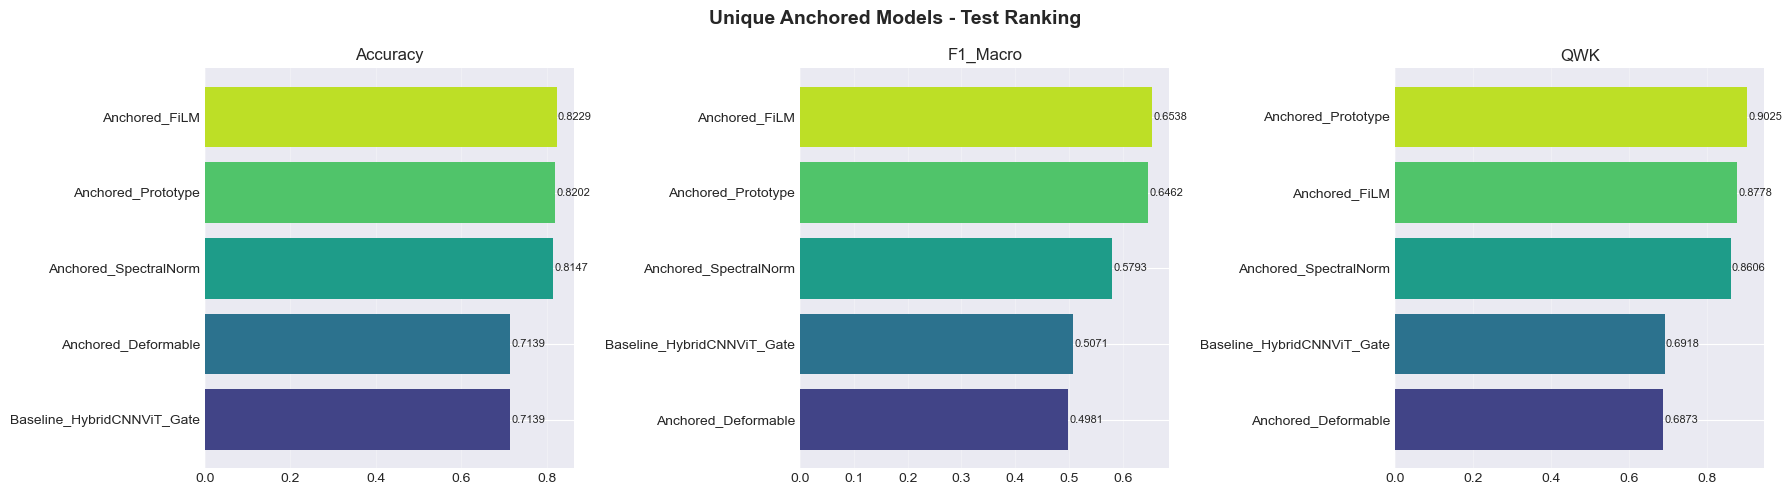

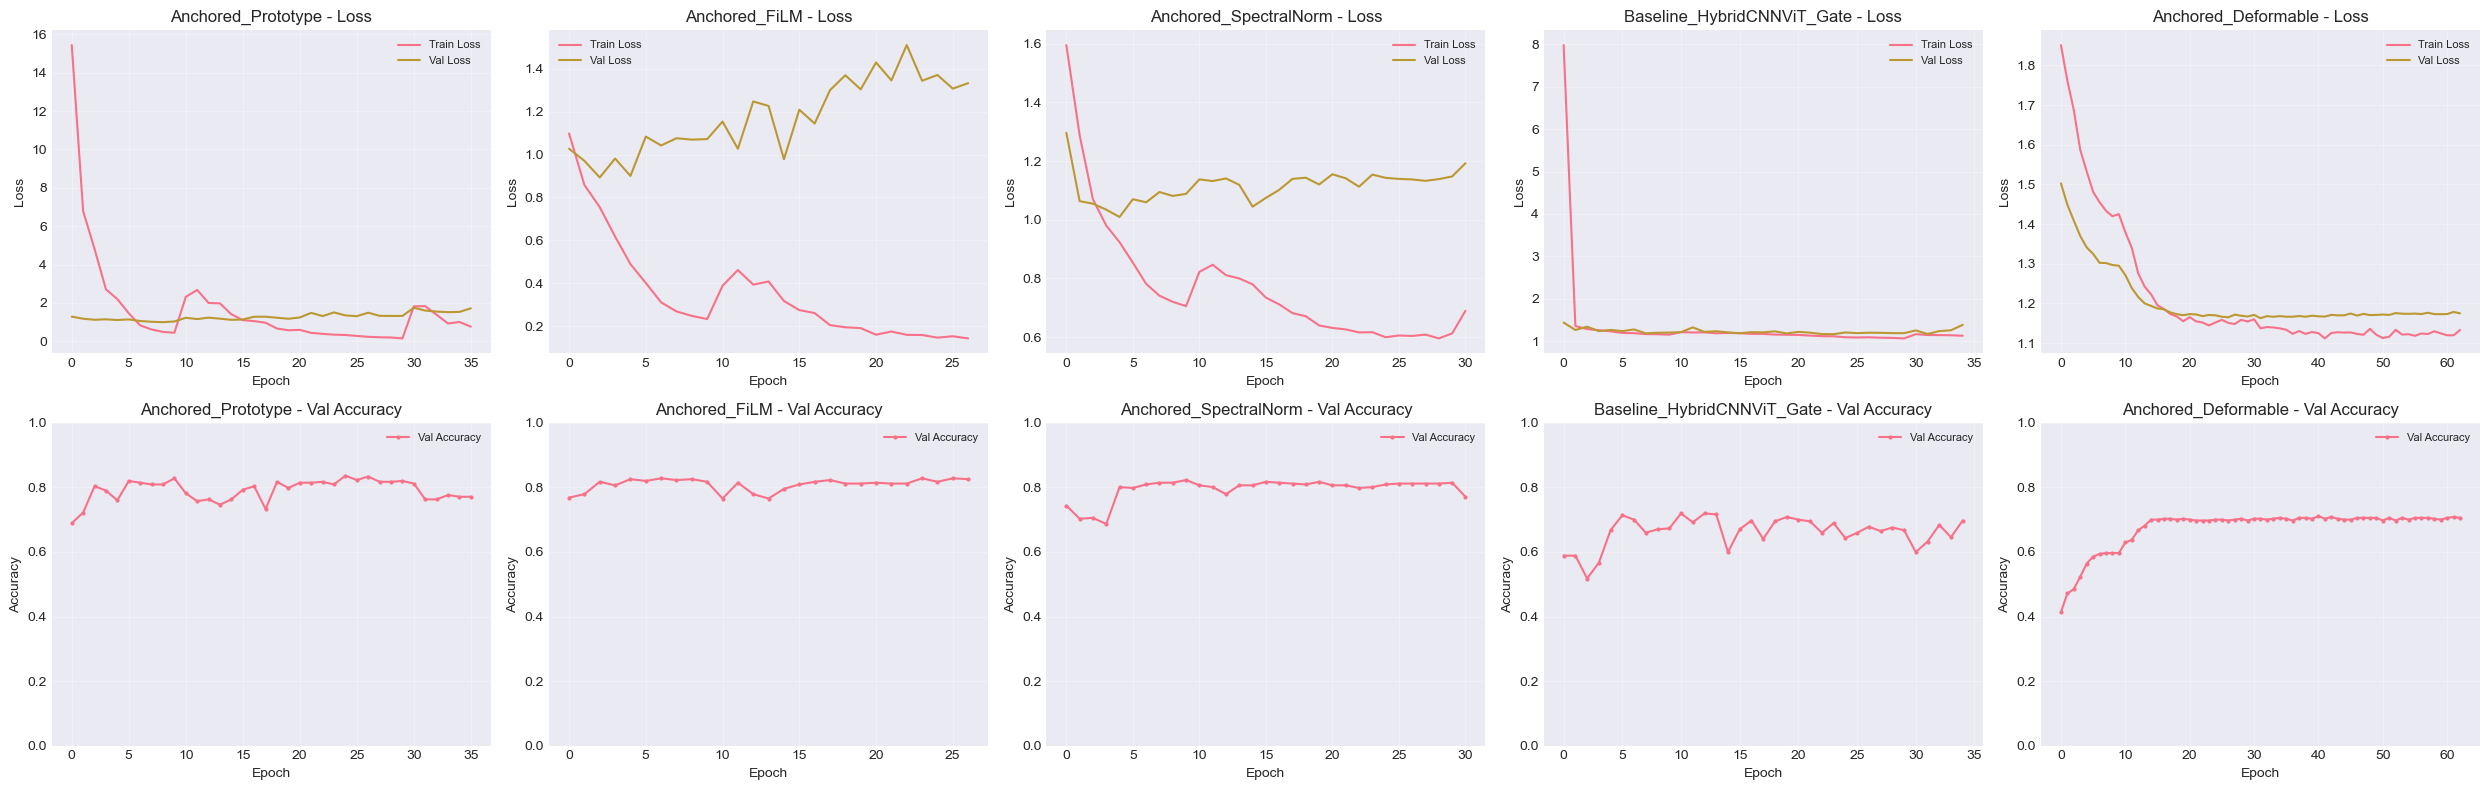

In [11]:
# 9) Plot: Ranking + Loss + Accuracy
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Unique Anchored Models - Test Ranking', fontsize=14, fontweight='bold')
for ax, metric in zip(axes, ['Accuracy', 'F1_Macro', 'QWK']):
    sdf = comparison_df.sort_values(metric, ascending=True)
    ax.barh(sdf['Model'], sdf[metric], color=plt.cm.viridis(np.linspace(0.2, 0.9, len(sdf))))
    ax.set_title(metric)
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(sdf[metric]):
        ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(results_dir / '00_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

model_names = comparison_df['Model'].tolist()
fig, axes = plt.subplots(2, len(model_names), figsize=(5*len(model_names), 8), sharex=False)
if len(model_names) == 1:
    axes = np.array(axes).reshape(2, 1)

for i, mname in enumerate(model_names):
    hp = results_dir / mname / 'training_history.json'
    if hp.exists():
        with open(hp, 'r', encoding='utf-8') as f:
            h = json.load(f)

        axes[0, i].plot(h.get('train_loss', []), label='Train Loss')
        axes[0, i].plot(h.get('val_loss', []), label='Val Loss')
        axes[0, i].set_title(mname + ' - Loss')
        axes[0, i].set_xlabel('Epoch')
        axes[0, i].set_ylabel('Loss')
        axes[0, i].grid(alpha=0.3)
        axes[0, i].legend(fontsize=8)

        axes[1, i].plot(h.get('val_acc', []), label='Val Accuracy', marker='o', markersize=2)
        axes[1, i].set_title(mname + ' - Val Accuracy')
        axes[1, i].set_xlabel('Epoch')
        axes[1, i].set_ylabel('Accuracy')
        axes[1, i].set_ylim([0, 1])
        axes[1, i].grid(alpha=0.3)
        axes[1, i].legend(fontsize=8)

plt.tight_layout()
plt.savefig(results_dir / '01_loss_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()

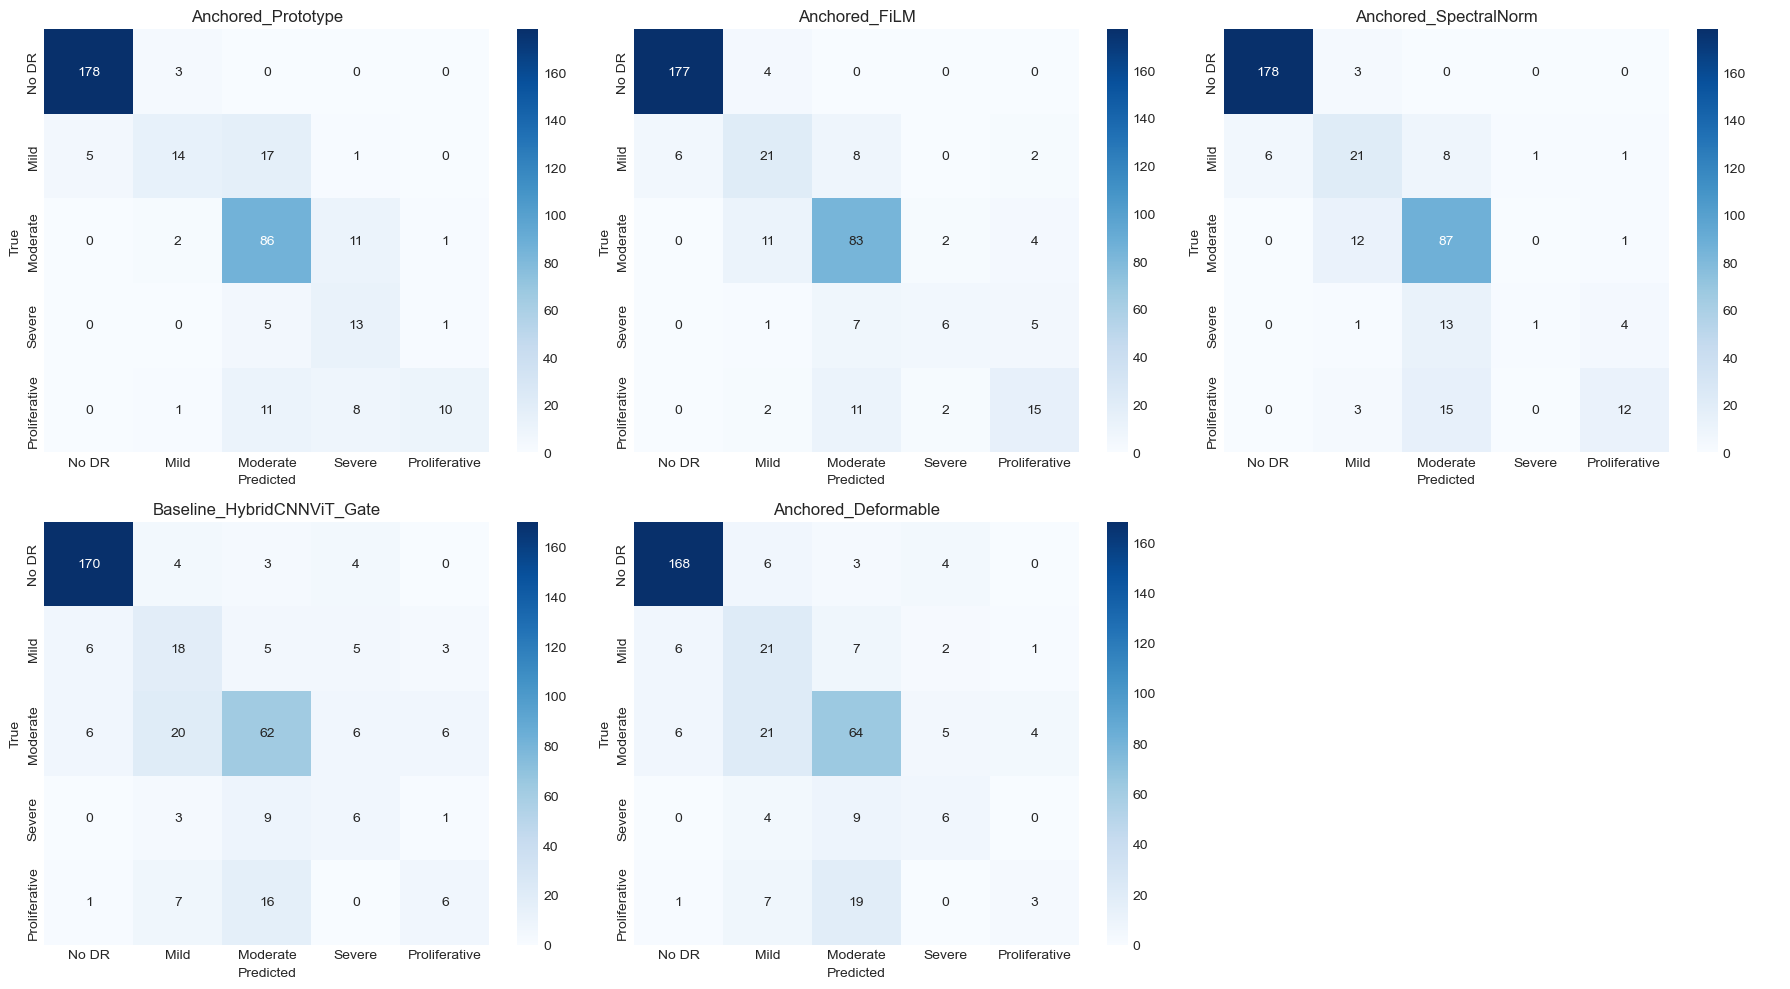

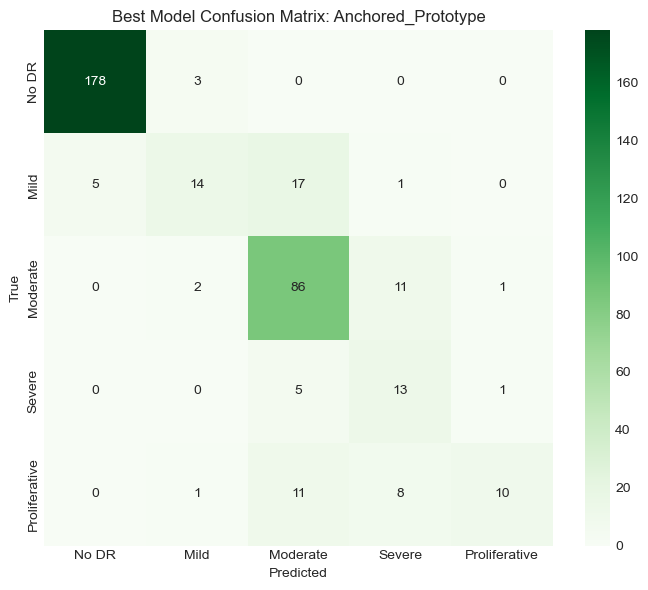

In [12]:
# 10) Plot: Confusion Matrices (all + best)
ok_models = [m for m in comparison_df['Model'].tolist() if m in all_results and 'confusion_matrix' in all_results[m]]

if len(ok_models) > 0:
    cols = min(3, len(ok_models))
    rows = int(np.ceil(len(ok_models) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    axes = np.array(axes).reshape(rows, cols)

    labels = ['No DR','Mild','Moderate','Severe','Proliferative']
    idx = 0
    for r in range(rows):
        for c in range(cols):
            ax = axes[r, c]
            if idx < len(ok_models):
                mname = ok_models[idx]
                cm = np.array(all_results[mname]['confusion_matrix'])
                sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                            xticklabels=labels, yticklabels=labels)
                ax.set_title(mname)
                ax.set_xlabel('Predicted')
                ax.set_ylabel('True')
            else:
                ax.axis('off')
            idx += 1

    plt.tight_layout()
    plt.savefig(results_dir / '02_confusion_matrices_all.png', dpi=150, bbox_inches='tight')
    plt.show()

    best_model = comparison_df.iloc[0]['Model']
    cm_best = np.array(all_results[best_model]['confusion_matrix'])
    plt.figure(figsize=(7,6))
    sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels, yticklabels=labels)
    plt.title('Best Model Confusion Matrix: ' + best_model)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(results_dir / '03_confusion_matrix_best.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No confusion matrix data found.')

## Run Notes

Calistirma sirasi:
1. Hucre 1-6 bir kez calistir
2. Hucre 7 ile tum egitimi baslat
3. Baglanti koparsa notebooku acip Hucre 7'yi yeniden calistir (checkpoint'ten devam eder)
4. Hucre 8-10 ile ozet ve tum gorselleri uret

## Architecture Diagram Export (Paper-Ready)

Bu bolum en iyi anchored modelin tam mimari akisini (input -> branchler -> fusion -> output + loss) tek bir sekilde cizer ve PNG olarak kaydeder.

Saved: results\unique_anchored_hybrid\04_best_model_full_architecture_horizontal.png


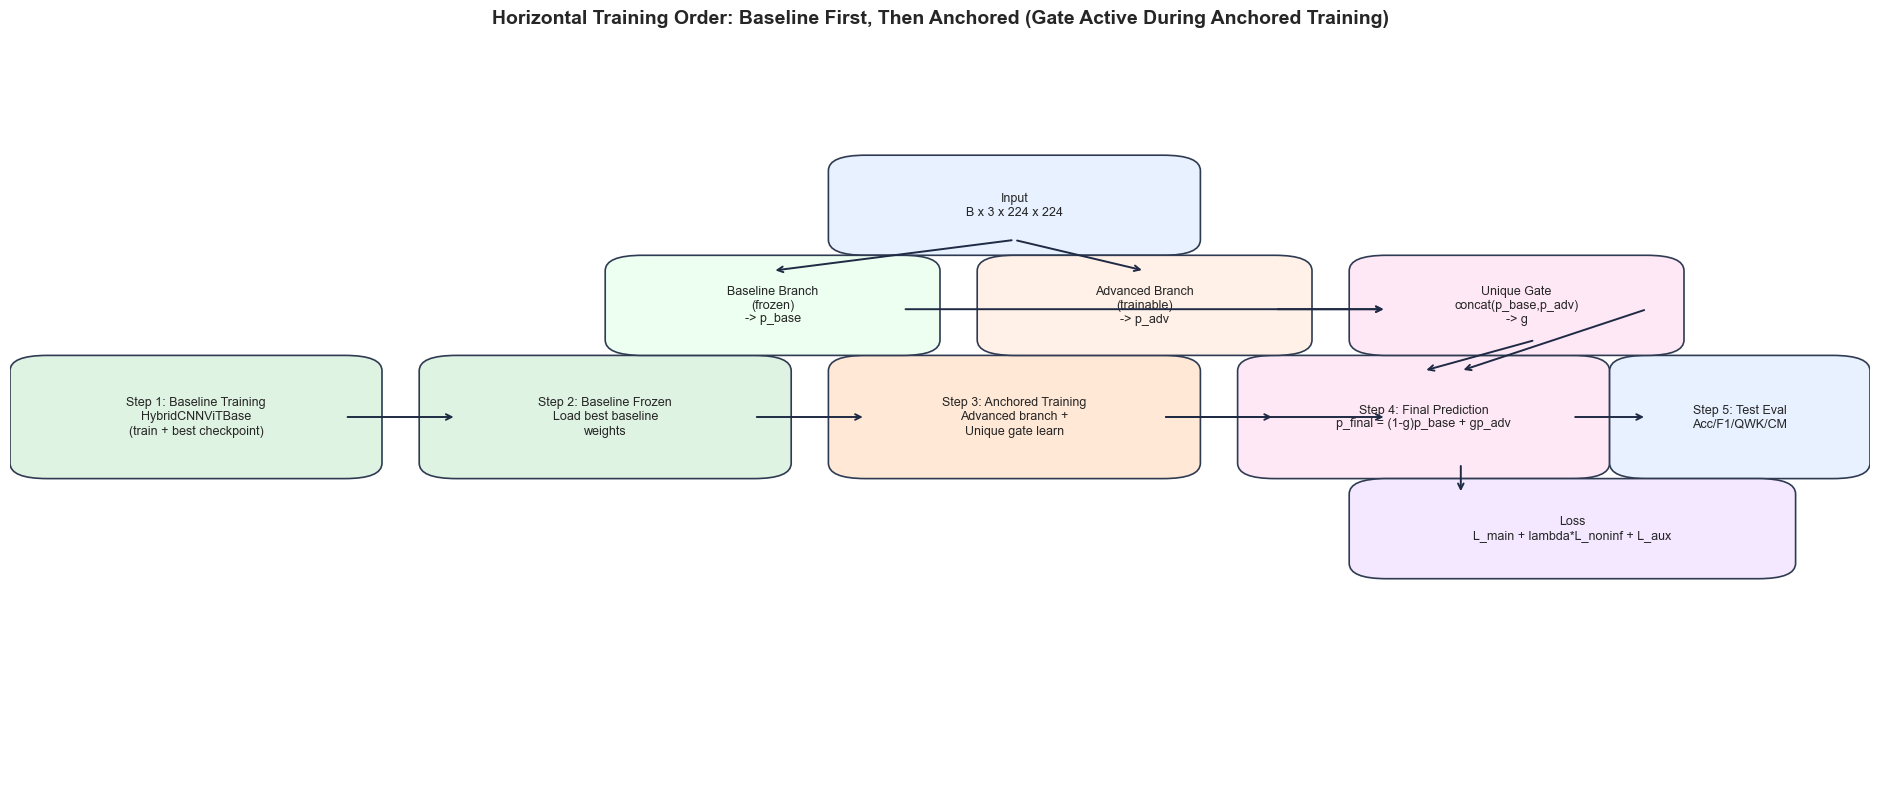

In [ ]:
# 11) Draw and Save Layer-Style Architecture Diagram (CNN-like Visual)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, Circle


def draw_stack(ax, x, y, w, h, n=5, dx=0.006, dy=0.006, fc="#d9c4a8", ec="#5c4d3a", label=""):
    for i in range(n):
        r = Rectangle((x + i * dx, y + i * dy), w, h, linewidth=1.0, edgecolor=ec, facecolor=fc, alpha=0.95)
        ax.add_patch(r)
    if label:
        ax.text(x + w * 0.5, y - 0.035, label, ha="center", va="top", fontsize=11, color="#222")


def draw_stage(ax, x, y, w, h, title, subtitle, n=5):
    draw_stack(ax, x, y, w, h, n=n, fc="#ccb79a", ec="#5f5242")
    ax.text(x + w * 0.5, y + h + 0.035, title, ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax.text(x + w * 0.5, y - 0.07, subtitle, ha="center", va="top", fontsize=10)


def arrow(ax, x1, y1, x2, y2, ls="-"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", lw=1.4, color="#303030", linestyle=ls))


def draw_prob_box(ax, x, y, w, h, probs, labels):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.01,rounding_size=0.01",
        linewidth=1.2, edgecolor="#8c5f2a", facecolor="#eab679"
    )
    ax.add_patch(box)

    ys = np.linspace(y + h - 0.02, y + 0.02, len(probs))
    for i, (p, lab, yy) in enumerate(zip(probs, labels, ys)):
        ax.text(x + 0.015, yy, f"{p:.2f}", va="center", ha="left", fontsize=10, color="white", fontweight="bold")
        ax.text(x + w + 0.01, yy, lab, va="center", ha="left", fontsize=10, color="#222")
        if i < len(probs) - 1:
            ax.plot([x, x + w], [yy - 0.022, yy - 0.022], color="#8c5f2a", lw=1.0, ls=(0, (3, 3)))

    ax.text(x + w * 0.5, y - 0.04, "Softmax", ha="center", va="top", fontsize=11, fontweight="bold")


fig, ax = plt.subplots(figsize=(22, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Input block (image placeholder style)
input_box = FancyBboxPatch((0.02, 0.34), 0.10, 0.42, boxstyle="round,pad=0.01", linewidth=1.1, edgecolor="#808080", facecolor="#ece6dc")
ax.add_patch(input_box)
ax.text(0.07, 0.80, "Input", ha="center", va="bottom", fontsize=15, fontweight="bold")
ax.text(0.07, 0.32, "B x 3 x 224 x 224", ha="center", va="top", fontsize=10)

# Baseline branch (upper lane)
draw_stage(ax, 0.16, 0.50, 0.07, 0.24, "Baseline CNN", "Conv + ReLU + Pool", n=4)
draw_stage(ax, 0.26, 0.53, 0.06, 0.18, "Baseline ViT", "Patch + Transformer", n=4)
base_fusion = FancyBboxPatch((0.35, 0.56), 0.10, 0.10, boxstyle="round,pad=0.02", linewidth=1.2, edgecolor="#3a6b46", facecolor="#d9f0dd")
ax.add_patch(base_fusion)
ax.text(0.40, 0.61, "p_base", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(0.40, 0.54, "Baseline Fusion", ha="center", va="top", fontsize=10)

# Advanced branch (lower lane)
draw_stage(ax, 0.16, 0.12, 0.07, 0.24, "Adv CNN", "ResNet50 + GAP", n=5)
draw_stage(ax, 0.26, 0.15, 0.06, 0.18, "Adv ViT", "ViT-B/16 cls", n=4)
adv_fusion = FancyBboxPatch((0.35, 0.18), 0.10, 0.10, boxstyle="round,pad=0.02", linewidth=1.2, edgecolor="#8a5a2b", facecolor="#ffe8d0")
ax.add_patch(adv_fusion)
ax.text(0.40, 0.23, "p_adv", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(0.40, 0.16, "Prototype Head", ha="center", va="top", fontsize=10)

# Gate and final fusion
gate_box = FancyBboxPatch((0.50, 0.34), 0.11, 0.20, boxstyle="round,pad=0.02", linewidth=1.2, edgecolor="#7a3f69", facecolor="#ffe3f5")
ax.add_patch(gate_box)
ax.text(0.555, 0.46, "Unique Gate", ha="center", va="center", fontsize=12, fontweight="bold")
ax.text(0.555, 0.40, "concat(p_base, p_adv)", ha="center", va="center", fontsize=9)
ax.text(0.555, 0.36, "g in [0,1]", ha="center", va="center", fontsize=10)

mix_box = FancyBboxPatch((0.65, 0.35), 0.12, 0.18, boxstyle="round,pad=0.02", linewidth=1.2, edgecolor="#5d4b8a", facecolor="#e7e2ff")
ax.add_patch(mix_box)
ax.text(0.71, 0.45, "p_final", ha="center", va="center", fontsize=12, fontweight="bold")
ax.text(0.71, 0.40, "(1-g)p_base + gp_adv", ha="center", va="center", fontsize=9)

# Flatten + dense style
flat = Rectangle((0.80, 0.20), 0.012, 0.50, linewidth=1.2, edgecolor="#5f5242", facecolor="#ccb79a")
ax.add_patch(flat)
ax.text(0.806, 0.15, "Flatten", ha="center", va="top", fontsize=11, fontweight="bold")

# Dense layers (node style)
dense_x = [0.84, 0.88, 0.92]
dense_n = [9, 7, 5]
for x, n in zip(dense_x, dense_n):
    ys = np.linspace(0.22, 0.68, n)
    for y in ys:
        ax.add_patch(Circle((x, y), 0.008, edgecolor="#1677a9", facecolor="#3fa7d6", linewidth=1.0))

# Simple connection lines between dense layers
for y1 in np.linspace(0.22, 0.68, dense_n[0]):
    for y2 in np.linspace(0.24, 0.66, dense_n[1]):
        if np.random.rand() < 0.28:
            ax.plot([dense_x[0], dense_x[1]], [y1, y2], color="#1b1b1b", lw=0.7, alpha=0.55)
for y1 in np.linspace(0.24, 0.66, dense_n[1]):
    for y2 in np.linspace(0.26, 0.64, dense_n[2]):
        if np.random.rand() < 0.35:
            ax.plot([dense_x[1], dense_x[2]], [y1, y2], color="#1b1b1b", lw=0.7, alpha=0.55)

# Output probability box
draw_prob_box(
    ax, 0.95, 0.32, 0.07, 0.30,
    probs=[0.12, 0.18, 0.46, 0.17, 0.07],
    labels=["No DR", "Mild", "Moderate", "Severe", "Prolif."]
)

# Arrows for processing order
arrow(ax, 0.12, 0.60, 0.16, 0.62)
arrow(ax, 0.12, 0.45, 0.16, 0.24)
arrow(ax, 0.23, 0.62, 0.26, 0.62)
arrow(ax, 0.23, 0.24, 0.26, 0.24)
arrow(ax, 0.32, 0.62, 0.35, 0.61)
arrow(ax, 0.32, 0.24, 0.35, 0.23)
arrow(ax, 0.45, 0.61, 0.50, 0.46)
arrow(ax, 0.45, 0.23, 0.50, 0.42)
arrow(ax, 0.61, 0.44, 0.65, 0.44)
arrow(ax, 0.77, 0.44, 0.80, 0.45)
arrow(ax, 0.812, 0.45, 0.84, 0.45)
arrow(ax, 0.92, 0.45, 0.95, 0.47)

# Training notes
ax.text(0.03, 0.05, "Order: Baseline train -> freeze baseline -> train Anchored (adv+gate) -> p_final -> test metrics", fontsize=10, color="#222")
ax.text(0.56, 0.08, "Loss: L_total = L_main + lambda*L_noninf + L_aux", fontsize=10, color="#4a3a75")

plt.title("Hybrid CNN+ViT Layer-Style Architecture (Baseline-Anchored Prototype)", fontsize=15, fontweight="bold")

arch_path = results_dir / "04_best_model_layer_style_architecture.png"
plt.savefig(arch_path, dpi=240, bbox_inches="tight")
print("Saved:", arch_path)
plt.show()